In [1]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent / "src"))
import config
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, BaseCrossValidator
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
import seaborn as sns
import numpy as np
import pandas as pd
panel_data_path = config.PROJECT_ROOT/ "data" / "panel_data_no_dupes.csv"
panel_data = pd.read_csv(panel_data_path)

In [2]:
panel_data.columns

Index(['Name', 'Year', 'Date', 'WeightClassKg', 'Sex', 'Age',
       'TimeCompetingYearEnd', 'NumberOfMeets', 'Goodlift', 'BestMeetOfYear',
       'AverageAttemptsMade', 'MostAttemptsMade', 'LeastAttemptsMade',
       'LastMeetAttemptsMade', 'MeetsSinceLastBombOut', 'NumberOfBombOuts',
       'PercentageImprovementGradientWithinYear',
       'ImprovementGradientWithinYear',
       'PercentageImprovementGradientTwoMeets', 'ImprovementGradientTwoMeets',
       'PercentageImprovementGradientBetweenYears',
       'ImprovementGradientBetweenYears', 'TimeSinceLastPBYearEnd',
       'PercentageBombOuts', 'ImprovementAccelerationForPercentage',
       'ImprovementAcceleration', 'FederationRankCapped',
       'FederationProportion', 'FederationCount', 'MeetsYoYChange',
       'AvgMeetsPerYear', 'BelowAvgMeets', 'CompetesNextYear',
       'WeightClassKgCode', 'F', 'M', 'Mx'],
      dtype='object')

In [3]:
features = ['Goodlift',
 'BestMeetOfYear',
 'TimeSinceLastPBYearEnd',
 'Age',
 'FederationProportion',
 'TimeCompetingYearEnd',
 'PercentageImprovementGradientWithinYear',
 'WeightClassKgCode',
 'PercentageImprovementGradientTwoMeets',
 'Year',
 'PercentageImprovementGradientBetweenYears',
 'AvgMeetsPerYear',
 'ImprovementAccelerationForPercentage',
 'NumberOfMeets',
 'AverageAttemptsMade',
    'CovidAffectedPrediction']

###TODO
#add this to data_transformation
panel_data['CovidAffectedPrediction'] = (
    panel_data['Year'].isin([2019, 2020, 2021])
).astype(int)

panel = panel_data.loc[:,features + ['Date'] + ['CompetesNextYear']]
panel['Date'] = pd.to_datetime(panel['Date'])
panel = panel.sort_values('Date', ascending= True)
panel = panel.drop(columns = 'Date')

In [4]:

#note the train set inclides the train AND validate from the feature selection notebook
train = panel[panel['Year']<=2023].copy()
test = panel[panel['Year']>2023].copy()

train_X = train.drop(columns = 'CompetesNextYear')
train_y = train['CompetesNextYear']

test_X = test.drop(columns = 'CompetesNextYear')
test_y = test['CompetesNextYear']

Note that early stopping was tried but model performed better without so will tune max_iter instead in GridSearchCV

In [5]:
class YearBasedTimeSeriesSplit(BaseCrossValidator):
    #see https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/model_selection/_split.py
    # inheriting from BaseCrossValidator to ensure compatibility with GridSearchCV
    
    def __init__(self, year_column='Year'):
        self.year_column = year_column
        self.exclude_val_years= [2020,2021,2022]

    def split(self, X, y=None, groups=None):
        #needed alongside _iter_test_indices to make sure splits are time aware
        #otherwise the training rows are just all rows that are not training rows which would create leakage in hyperparam tuning
        
        years = sorted(X[self.year_column].unique())
        for i in range(1, len(years)):
            val_year = years[i]
            if val_year in self.exclude_val_years:
                continue
            train_years = years[:i]
            train_idx = np.where(X[self.year_column].isin(train_years))[0]
            val_idx = np.where(X[self.year_column] == val_year)[0]

            #parent class uses yield in implementation of split() so will use here
            yield train_idx, val_idx
        
    def _iter_test_indices(self, X=None, y=None, groups=None):
        years = sorted(X[self.year_column].unique())
        for i in range(1, len(years)):
            val_year = years[i]
            yield np.where(X[self.year_column] == val_year)[0]

    def get_n_splits(self, X=None, y=None, groups=None):
        #returns the number of folds the splitter will generate. 
        years = X[self.year_column].unique()
        return len(years) - 1

In [6]:
year_cv = YearBasedTimeSeriesSplit(year_column='Year')

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [200, 500, 1000],
    'max_depth': [3, 6, 9]
}

grid_search_f1 = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=year_cv,
    n_jobs=-1,
    verbose=1
)

In [7]:
grid_search_f1.fit(train_X, train_y)

Fitting 8 folds for each of 27 candidates, totalling 216 fits


C:\Users\bnpar\miniconda3\envs\powerlifting\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 6, ...], 'max_iter': [200, 500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",YearBasedTime...column='Year')
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter ca

In [8]:
# grid_search_recall = GridSearchCV(
#     HistGradientBoostingClassifier(random_state=42),
#     param_grid,
#     scoring='recall',
#     cv=year_cv,
#     n_jobs=-1,
#     verbose=1
# )

In [9]:
#grid_search_recall.fit(train_X,train_y)

print(f"Best params (F1):     {grid_search_f1.best_params_}")
# print(f"Best params (Recall): {grid_search_recall.best_params_}")

Fitting 8 folds for each of 27 candidates, totalling 216 fits


C:\Users\bnpar\miniconda3\envs\powerlifting\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params (F1):     {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 1000}
Best params (Recall): {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 1000}


<Axes: xlabel='param_max_depth', ylabel='param_learning_rate'>

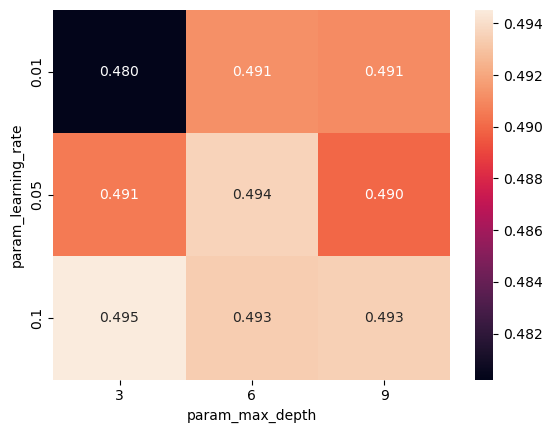

In [20]:


best_max_iter = grid_search_f1.best_params_['max_iter']
best_learning_rate = grid_search_f1.best_params_['learning_rate']
best_max_depth = grid_search_f1.best_params_['max_depth']

results_df = pd.DataFrame(grid_search_f1.cv_results_)

pivot = results_df[results_df['param_max_iter'] == best_max_iter].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)
sns.heatmap(pivot, annot=True, fmt='.3f')

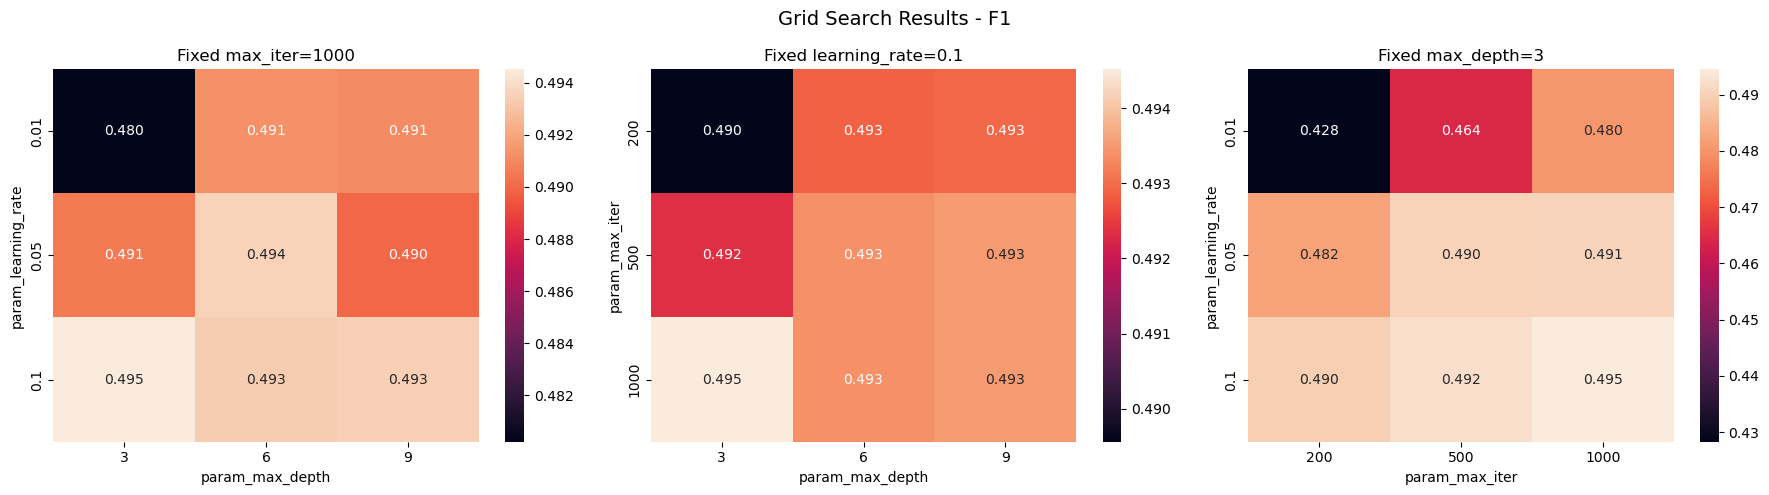

In [22]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# fix max_iter, plot learning_rate vs max_depth
pivot1 = results_df[results_df['param_max_iter'] == best_max_iter].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)
sns.heatmap(pivot1, annot=True, fmt='.3f', ax=axes[0])
axes[0].set_title(f'Fixed max_iter={best_max_iter}')

# fix learning_rate, plot max_iter vs max_depth
pivot2 = results_df[results_df['param_learning_rate'] == best_learning_rate].pivot_table(
    values='mean_test_score',
    index='param_max_iter',
    columns='param_max_depth'
)
sns.heatmap(pivot2, annot=True, fmt='.3f', ax=axes[1])
axes[1].set_title(f'Fixed learning_rate={best_learning_rate}')

# fix max_depth, plot learning_rate vs max_iter
pivot3 = results_df[results_df['param_max_depth'] == best_max_depth].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_iter'
)
sns.heatmap(pivot3, annot=True, fmt='.3f', ax=axes[2])
axes[2].set_title(f'Fixed max_depth={best_max_depth}')

plt.suptitle('Grid Search Results - F1', fontsize=14)
plt.tight_layout()
plt.show()


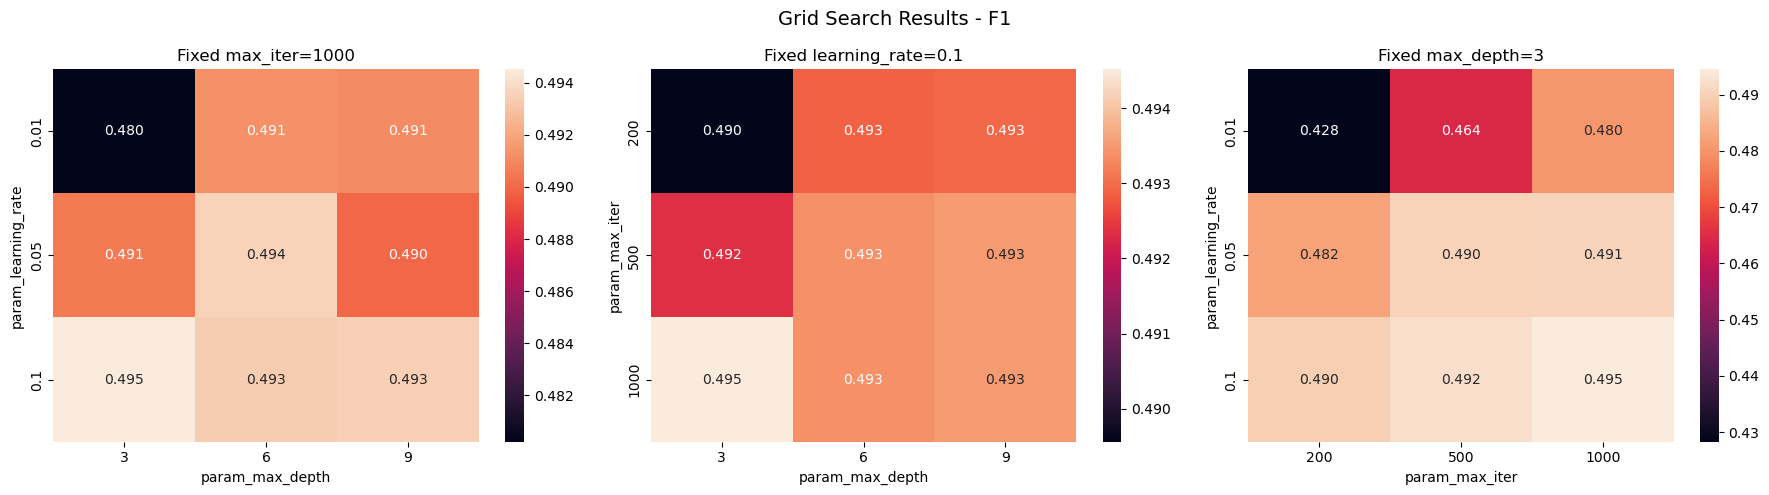

In [22]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# fix max_iter, plot learning_rate vs max_depth
pivot1 = results_df[results_df['param_max_iter'] == best_max_iter].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)
sns.heatmap(pivot1, annot=True, fmt='.3f', ax=axes[0])
axes[0].set_title(f'Fixed max_iter={best_max_iter}')

# fix learning_rate, plot max_iter vs max_depth
pivot2 = results_df[results_df['param_learning_rate'] == best_learning_rate].pivot_table(
    values='mean_test_score',
    index='param_max_iter',
    columns='param_max_depth'
)
sns.heatmap(pivot2, annot=True, fmt='.3f', ax=axes[1])
axes[1].set_title(f'Fixed learning_rate={best_learning_rate}')

# fix max_depth, plot learning_rate vs max_iter
pivot3 = results_df[results_df['param_max_depth'] == best_max_depth].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_iter'
)
sns.heatmap(pivot3, annot=True, fmt='.3f', ax=axes[2])
axes[2].set_title(f'Fixed max_depth={best_max_depth}')

plt.suptitle('Grid Search Results - F1', fontsize=14)
plt.tight_layout()
plt.show()


In [23]:
param_grid = {
    'learning_rate': [0.075, 0.1, 0.15],
    'max_iter': [750, 1000, 1300],
    'max_depth': [3, 4, 5]
}

grid_search_f1_2 = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=year_cv,
    n_jobs=-1,
    verbose=1
)

grid_search_f1_2.fit(train_X, train_y)

Fitting 8 folds for each of 27 candidates, totalling 216 fits


C:\Users\bnpar\miniconda3\envs\powerlifting\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.075, 0.1, ...], 'max_depth': [3, 4, ...], 'max_iter': [750, 1000, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",YearBasedTime...column='Year')
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter c

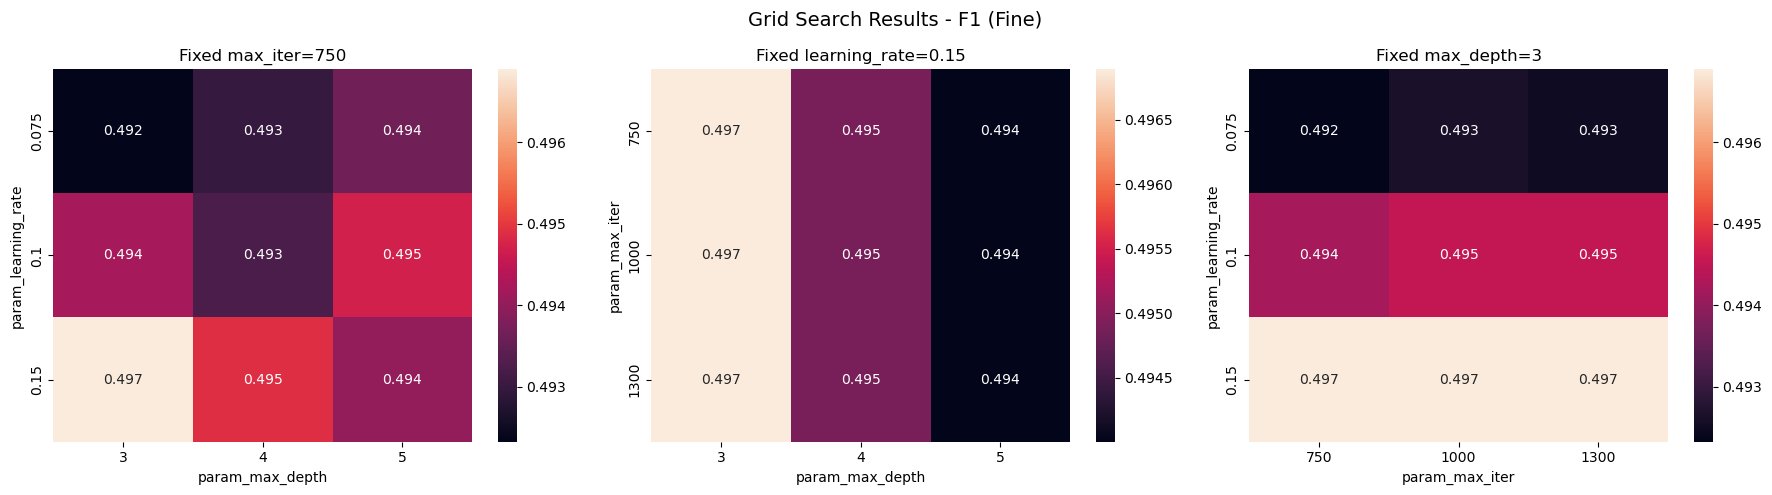

In [26]:
import matplotlib.pyplot as plt

fine_best_max_iter = grid_search_f1_2.best_params_['max_iter']
fine_best_learning_rate = grid_search_f1_2.best_params_['learning_rate']
fine_best_max_depth = grid_search_f1_2.best_params_['max_depth']

fine_results_df = pd.DataFrame(grid_search_f1_2.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pivot1 = fine_results_df[fine_results_df['param_max_iter'] == fine_best_max_iter].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)
sns.heatmap(pivot1, annot=True, fmt='.3f', ax=axes[0])
axes[0].set_title(f'Fixed max_iter={fine_best_max_iter}')

pivot2 = fine_results_df[fine_results_df['param_learning_rate'] == fine_best_learning_rate].pivot_table(
    values='mean_test_score',
    index='param_max_iter',
    columns='param_max_depth'
)
sns.heatmap(pivot2, annot=True, fmt='.3f', ax=axes[1])
axes[1].set_title(f'Fixed learning_rate={fine_best_learning_rate}')

pivot3 = fine_results_df[fine_results_df['param_max_depth'] == fine_best_max_depth].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_iter'
)
sns.heatmap(pivot3, annot=True, fmt='.3f', ax=axes[2])
axes[2].set_title(f'Fixed max_depth={fine_best_max_depth}')

plt.suptitle('Grid Search Results - F1 (Fine)', fontsize=14)
plt.tight_layout()
plt.show()



In [27]:
param_grid = {
    'learning_rate': [0.125, 0.15, 0.175],
    'max_iter': [800, 900],
    'max_depth': [2,3]
}

grid_search_f1_3 = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=year_cv,
    n_jobs=-1,
    verbose=1
)

grid_search_f1_3.fit(train_X, train_y)

Fitting 8 folds for each of 12 candidates, totalling 96 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.125, 0.15, ...], 'max_depth': [2, 3], 'max_iter': [800, 900]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",YearBasedTime...column='Year')
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

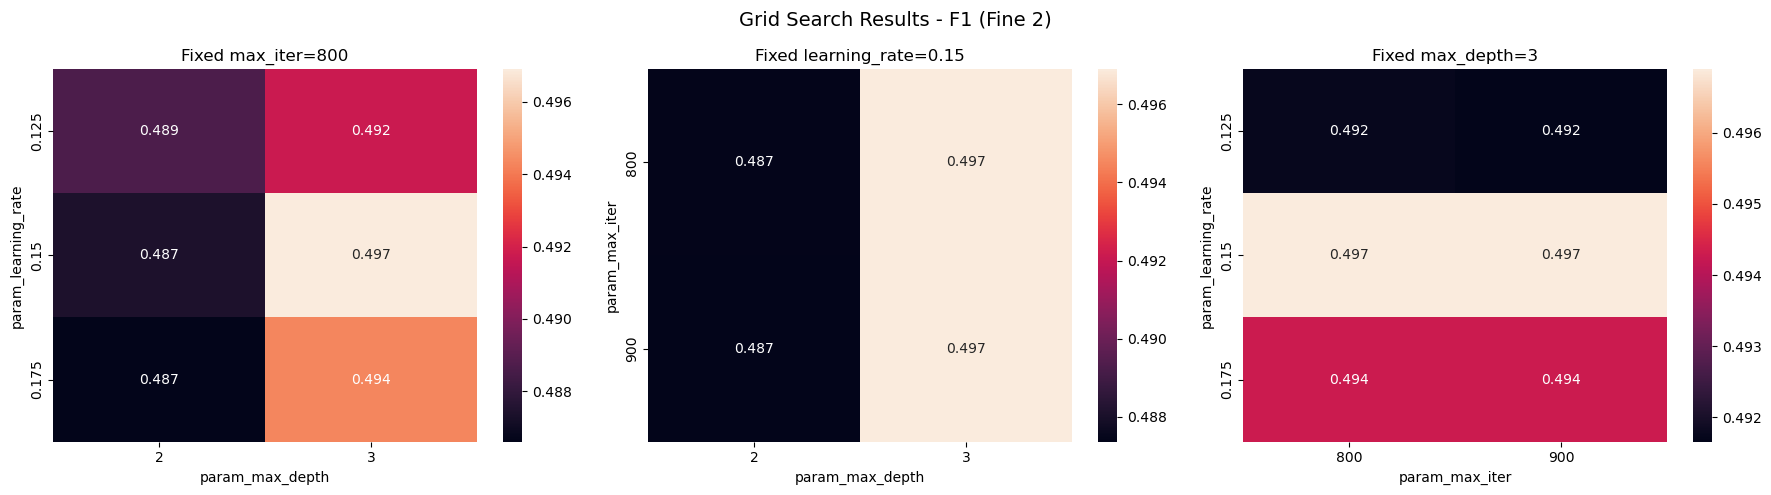

In [28]:
import matplotlib.pyplot as plt

fine2_best_max_iter = grid_search_f1_3.best_params_['max_iter']
fine2_best_learning_rate = grid_search_f1_3.best_params_['learning_rate']
fine2_best_max_depth = grid_search_f1_3.best_params_['max_depth']

fine2_results_df = pd.DataFrame(grid_search_f1_3.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pivot1 = fine2_results_df[fine2_results_df['param_max_iter'] == fine2_best_max_iter].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_depth'
)
sns.heatmap(pivot1, annot=True, fmt='.3f', ax=axes[0])
axes[0].set_title(f'Fixed max_iter={fine2_best_max_iter}')

pivot2 = fine2_results_df[fine2_results_df['param_learning_rate'] == fine2_best_learning_rate].pivot_table(
    values='mean_test_score',
    index='param_max_iter',
    columns='param_max_depth'
)
sns.heatmap(pivot2, annot=True, fmt='.3f', ax=axes[1])
axes[1].set_title(f'Fixed learning_rate={fine2_best_learning_rate}')

pivot3 = fine2_results_df[fine2_results_df['param_max_depth'] == fine2_best_max_depth].pivot_table(
    values='mean_test_score',
    index='param_learning_rate',
    columns='param_max_iter'
)
sns.heatmap(pivot3, annot=True, fmt='.3f', ax=axes[2])
axes[2].set_title(f'Fixed max_depth={fine2_best_max_depth}')

plt.suptitle('Grid Search Results - F1 (Fine 2)', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
results_df = pd.DataFrame(grid_search_f1_3.cv_results_)

# get scores for each fold for the best parameter combination
best_index = grid_search_f1_3.best_index_

fold_scores = {col: results_df.loc[best_index, col] 
               for col in results_df.columns 
               if col.startswith('split')}

for fold, score in fold_scores.items():
    print(f"{fold}: {score:.4f}")

split0_test_score: 0.6031
split1_test_score: 0.5669
split2_test_score: 0.6053
split3_test_score: 0.3266
split4_test_score: 0.0547
split5_test_score: 0.5037
split6_test_score: 0.6719
split7_test_score: 0.6431


In [ ]:
best_clf = HistGradientBoostingClassifier(
    **grid_search_f1_3.best_params_,
    random_state=42
)
best_clf.fit(full_train_X, full_train_y)